In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/sebastiangutierrezbernal/Desktop/Personal/Quantum Research/info-patterns-repo


In [2]:
from src.parameters import (ELLIPSOID_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, DEFAULT_FARFIELD_PARAMS, DEFAULT_GAUSSIAN_FIELD_PARAMS, 
                            DEFAULT_DYADS_PARAMS, DEFAULT_LIBRATION_ANGLE_DEG, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_SAVE_TYPE, DEFAULT_2D_PLANES, DEFAULT_2D_NORMALIZE, 
                            DEFAULT_2D_FILL)
from src.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material)
from src.light_matter_interaction_simulation import (incident_field, field_propagation, simulation_from_geometry, scattered_farfield_from_simulation, librational_scattered_farfield)
from src.information_patterns_simulation import (info_patterns_from_scattered_field)
from src.plots import (set_plot_style, plot3d_info_patterns, plot2d_info_patterns)
set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "lib_ellipsoid_results"

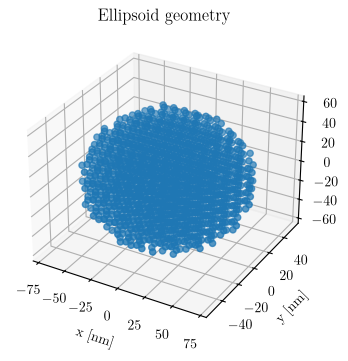

Geometry shape: (1383, 3)
Geometry center: [ 0.0000000e+00 -1.5101567e-06  4.1539652e-06]
Material: <pyGDM2.materials.sio2 object at 0x118dc5610>


In [3]:
geometry = nanoparticle_geometry(**ELLIPSOID_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(geometry[:, 0], geometry[:, 1], geometry[:, 2], s=20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("y [nm]")
ax.set_zlabel("z [nm]")
ax.set_title("Ellipsoid geometry")
plt.show()

print("Geometry shape:", geometry.shape)
print("Geometry center:", np.mean(geometry, axis=0))
print("Material:", material)

In [4]:
farfield_params = DEFAULT_FARFIELD_PARAMS
Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]

efield = incident_field(**DEFAULT_GAUSSIAN_FIELD_PARAMS)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 1595.8ms, inv.: 852.8ms, repropa.: 262.6ms (1 field configs), tot: 2711.4ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 102.7ms, inv.: 931.4ms, repropa.: 27.8ms (1 field configs), tot: 1062.3ms


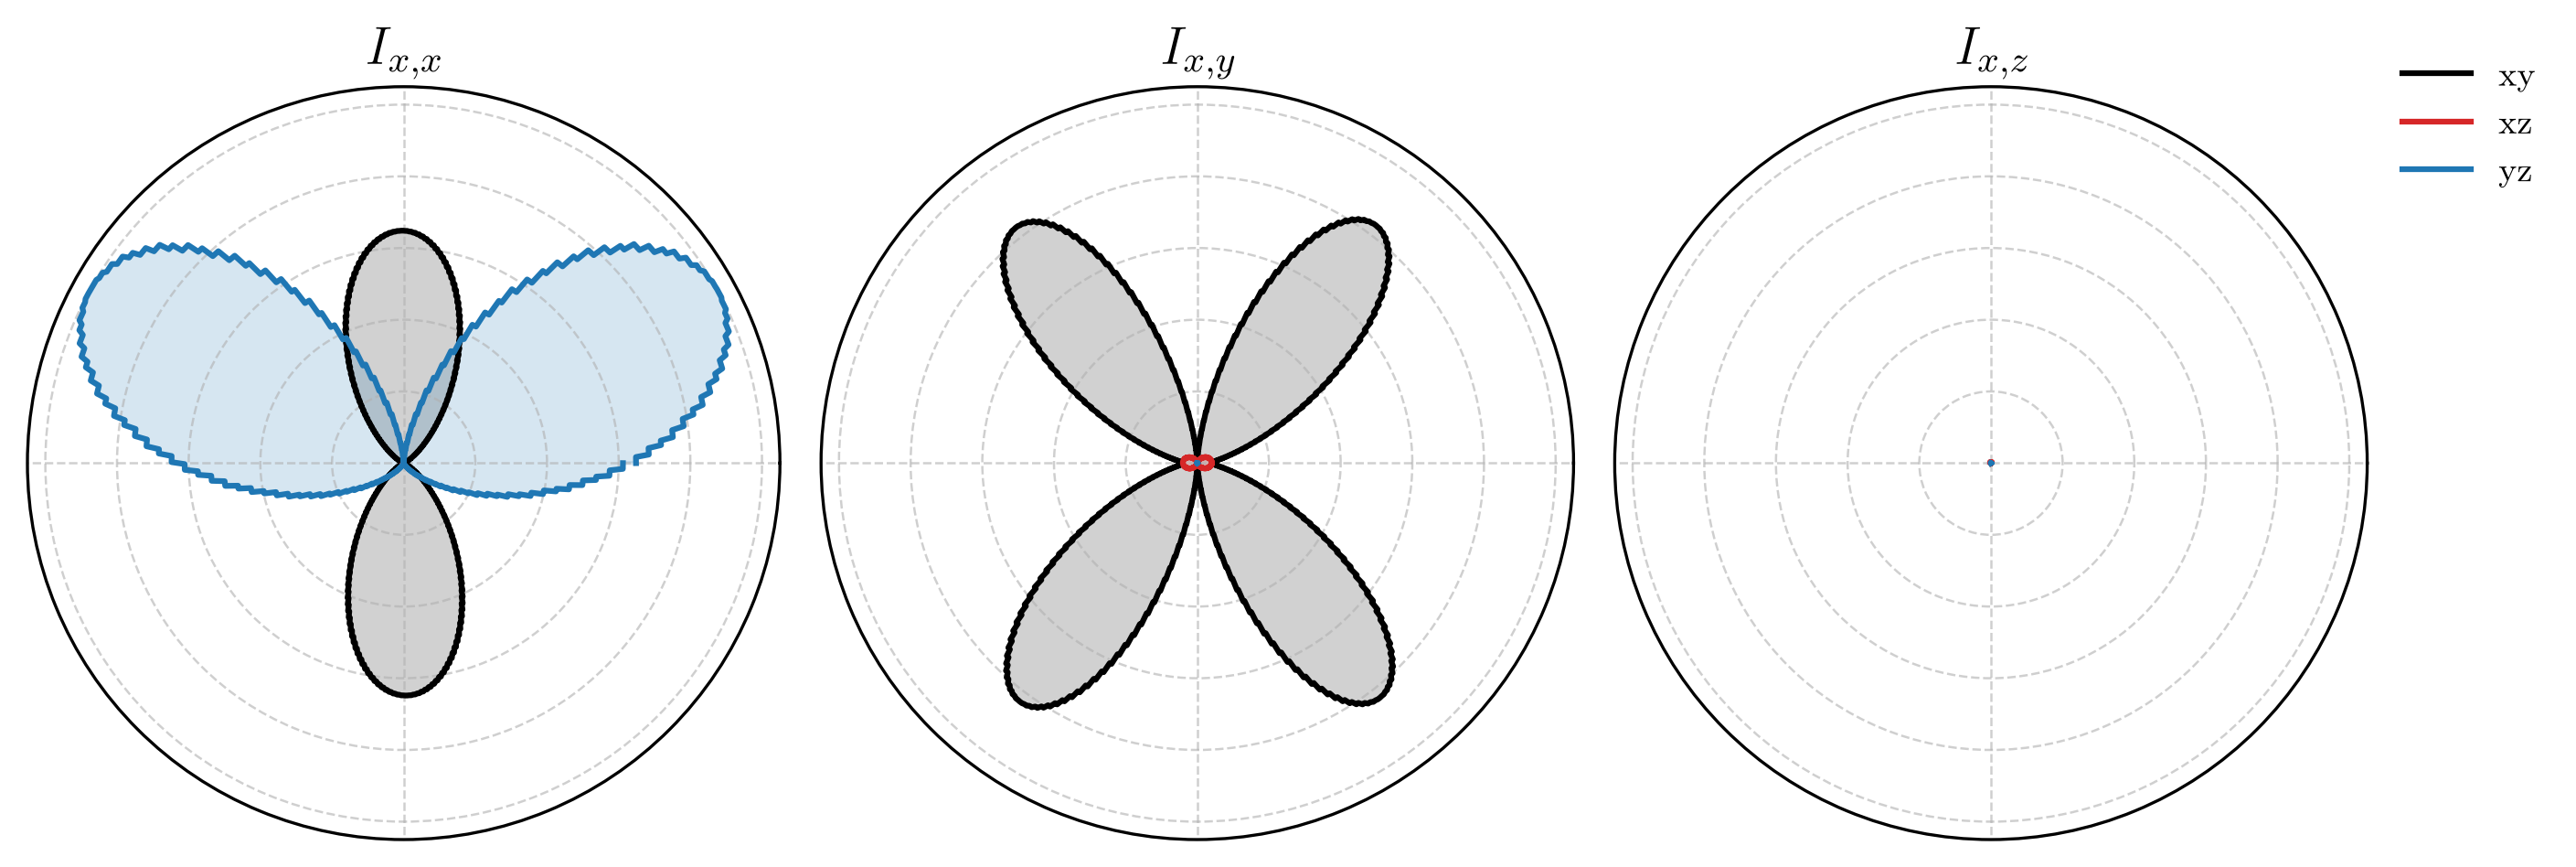

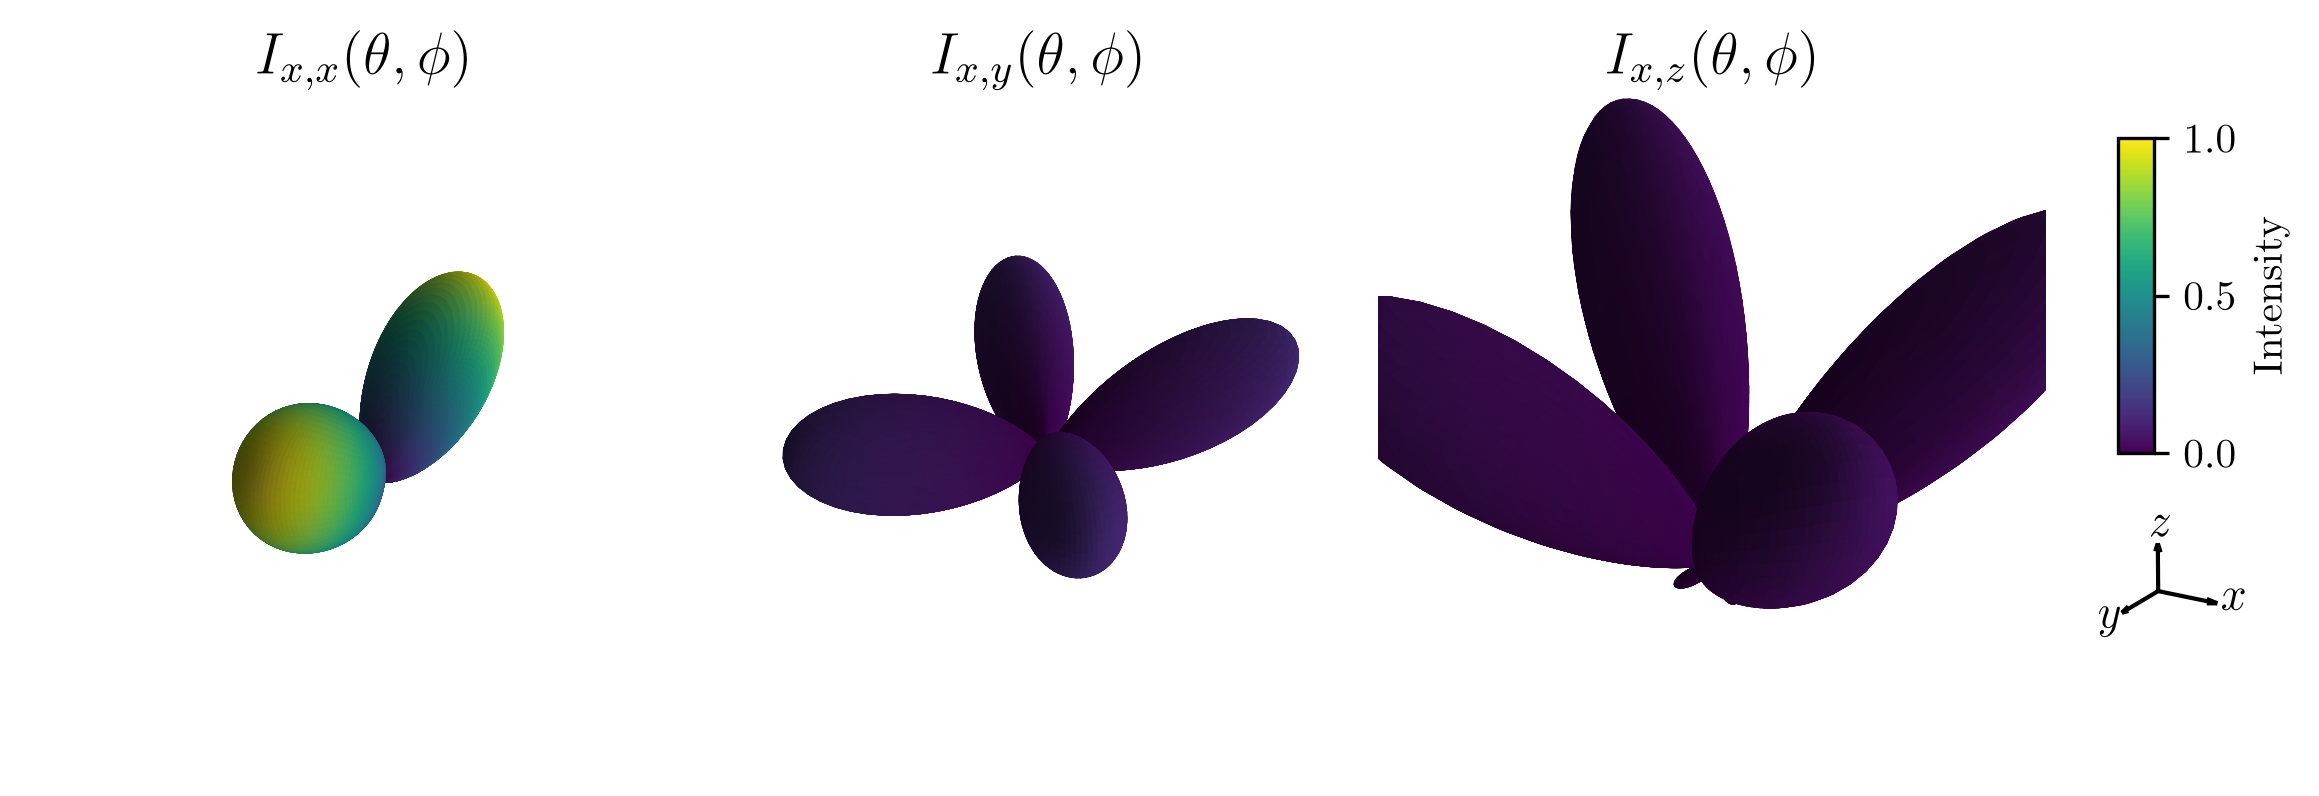

In [ ]:
E_plus_x, E_minus_x, dE_x = librational_scattered_farfield(geometry=geometry, step_nm=ELLIPSOID_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=0, 
                                                           angle_deg=DEFAULT_LIBRATION_ANGLE_DEG, **farfield_params)
I_x_total, I_x_Ex, I_x_Ey, I_x_Ez = info_patterns_from_scattered_field(dE=dE_x, delta_mu=np.deg2rad(DEFAULT_LIBRATION_ANGLE_DEG), wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, 
                     figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_x_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, scale_list=[0.28, 0.34, 0.36], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_x_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 145.5ms, inv.: 1019.2ms, repropa.: 21.1ms (1 field configs), tot: 1186.0ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 221.7ms, inv.: 970.9ms, repropa.: 35.5ms (1 field configs), tot: 1231.4ms


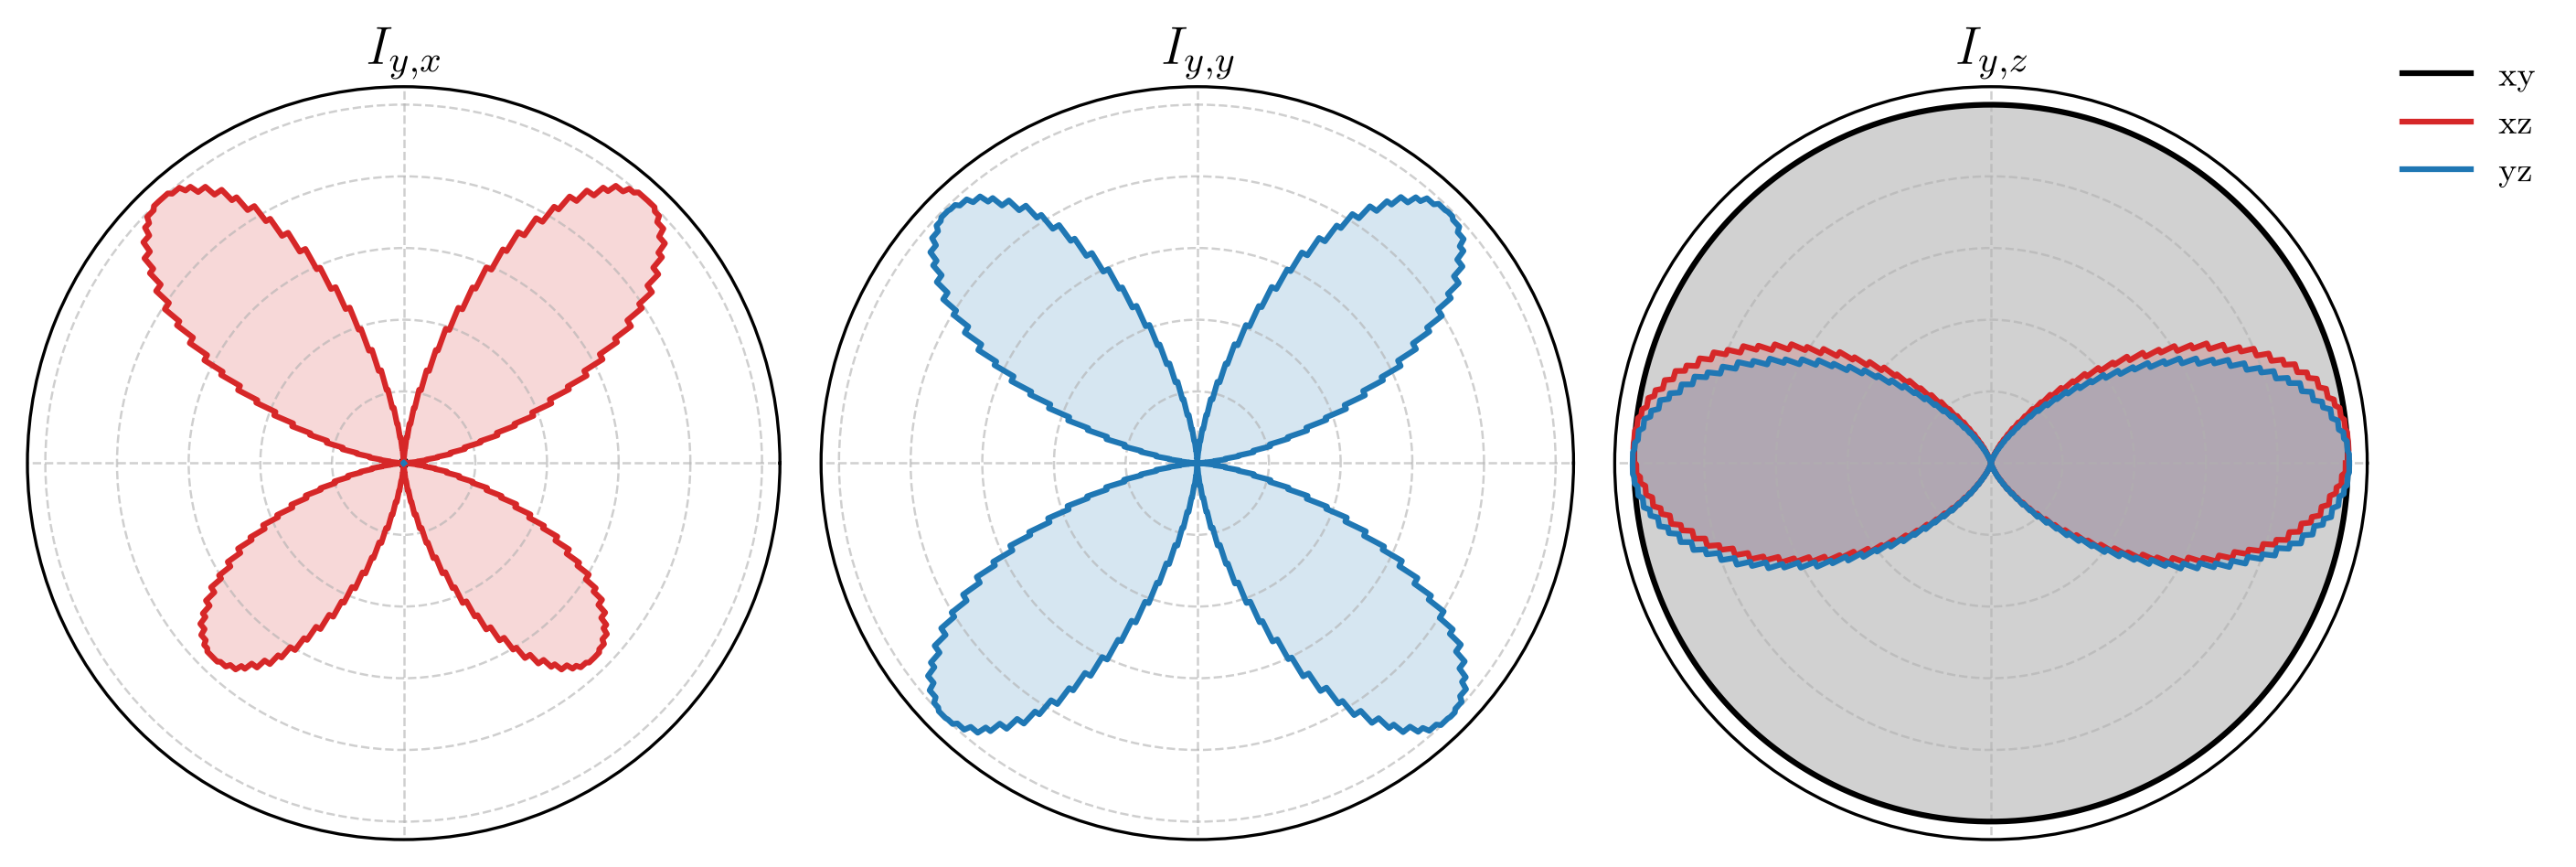

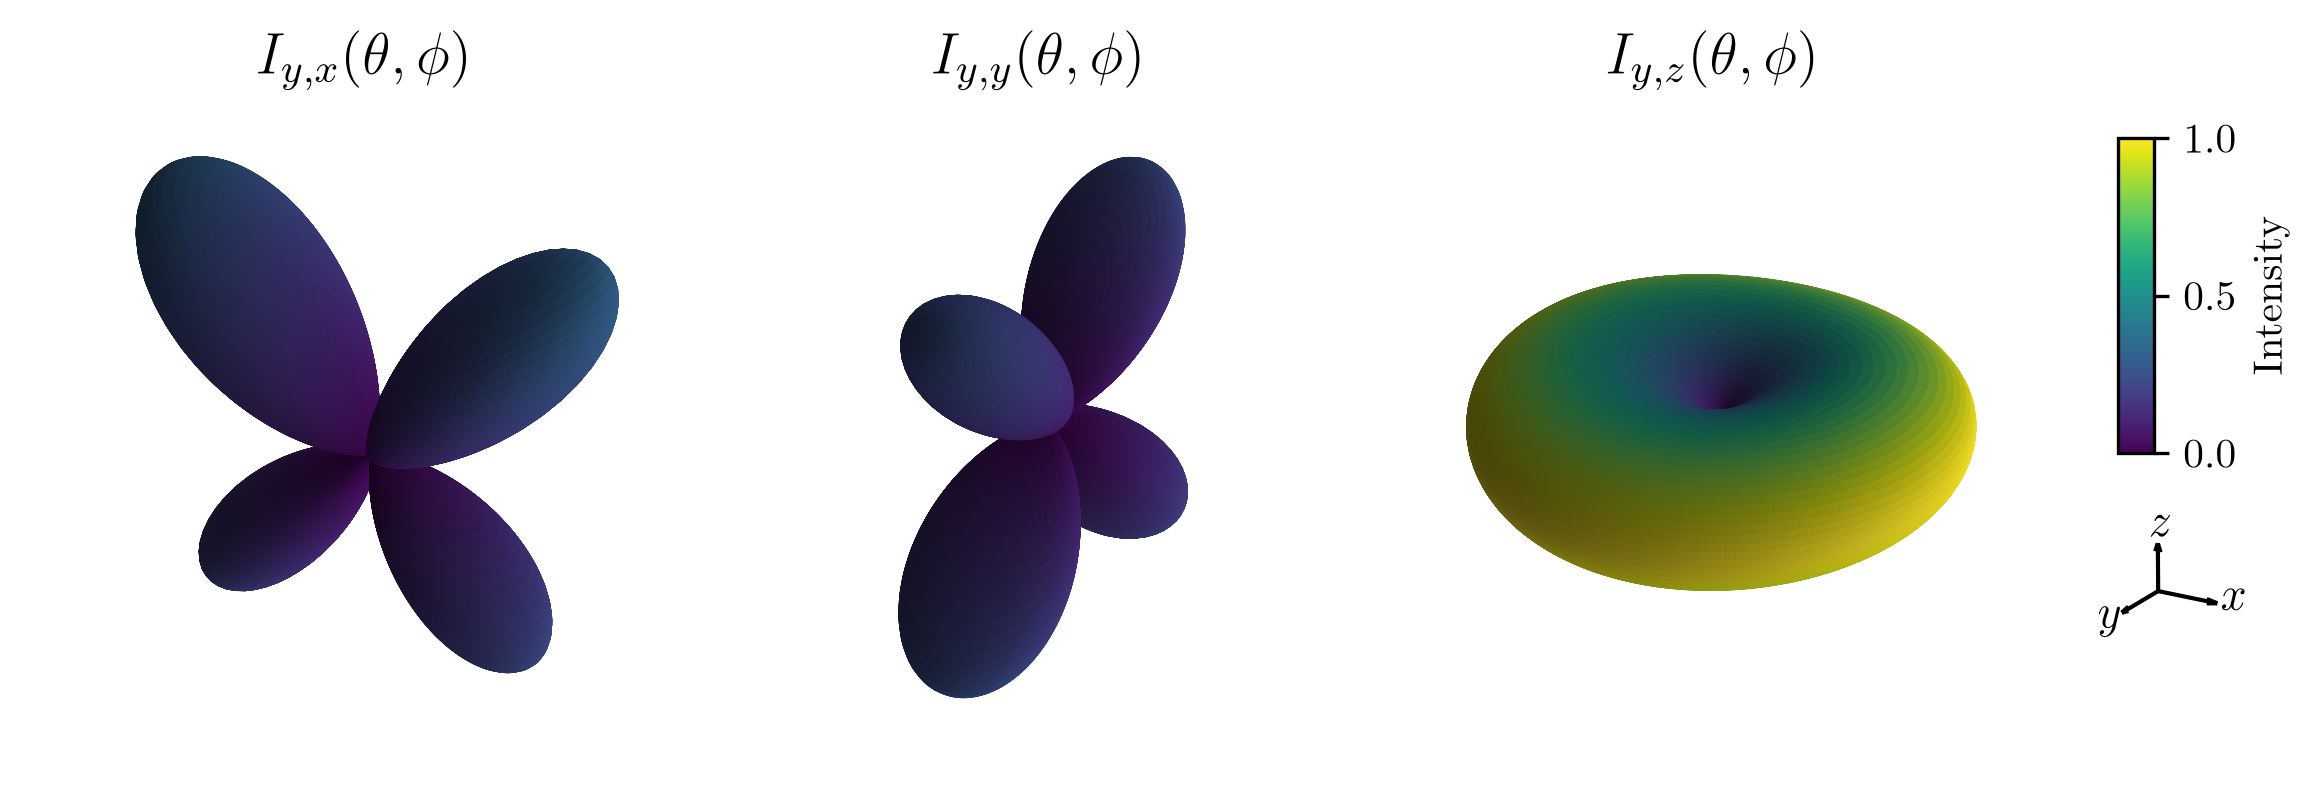

In [6]:
E_plus_y, E_minus_y, dE_y = librational_scattered_farfield(geometry=geometry, step_nm=ELLIPSOID_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=1, 
                                                           angle_deg=DEFAULT_LIBRATION_ANGLE_DEG, **farfield_params)
I_y_total, I_y_Ex, I_y_Ey, I_y_Ez = info_patterns_from_scattered_field(dE=dE_y, delta_mu=np.deg2rad(DEFAULT_LIBRATION_ANGLE_DEG), wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, 
                     figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_y_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, scale_list=[0.34, 0.4, 0.34], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_y_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 86.6ms, inv.: 881.7ms, repropa.: 21.5ms (1 field configs), tot: 989.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 167.9ms, inv.: 1196.1ms, repropa.: 35.2ms (1 field configs), tot: 1403.8ms


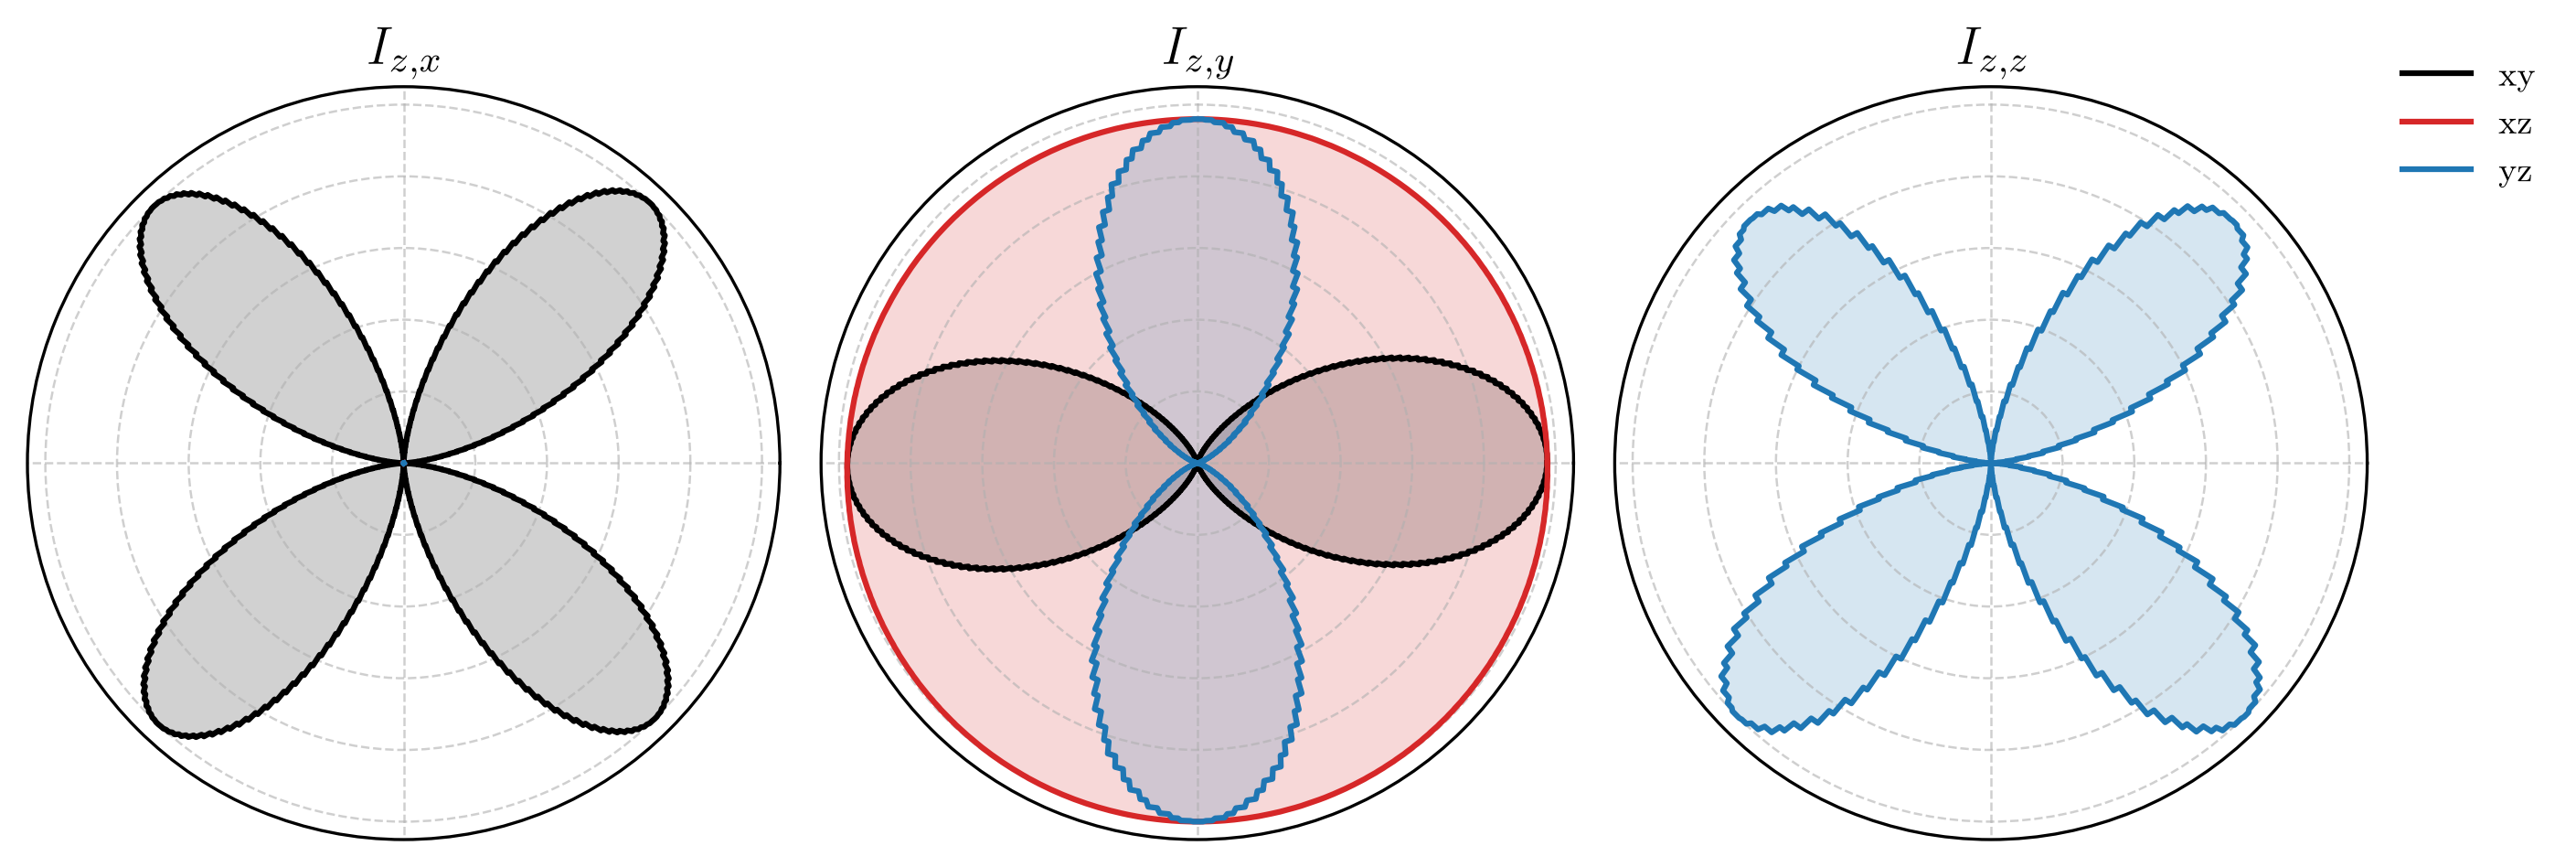

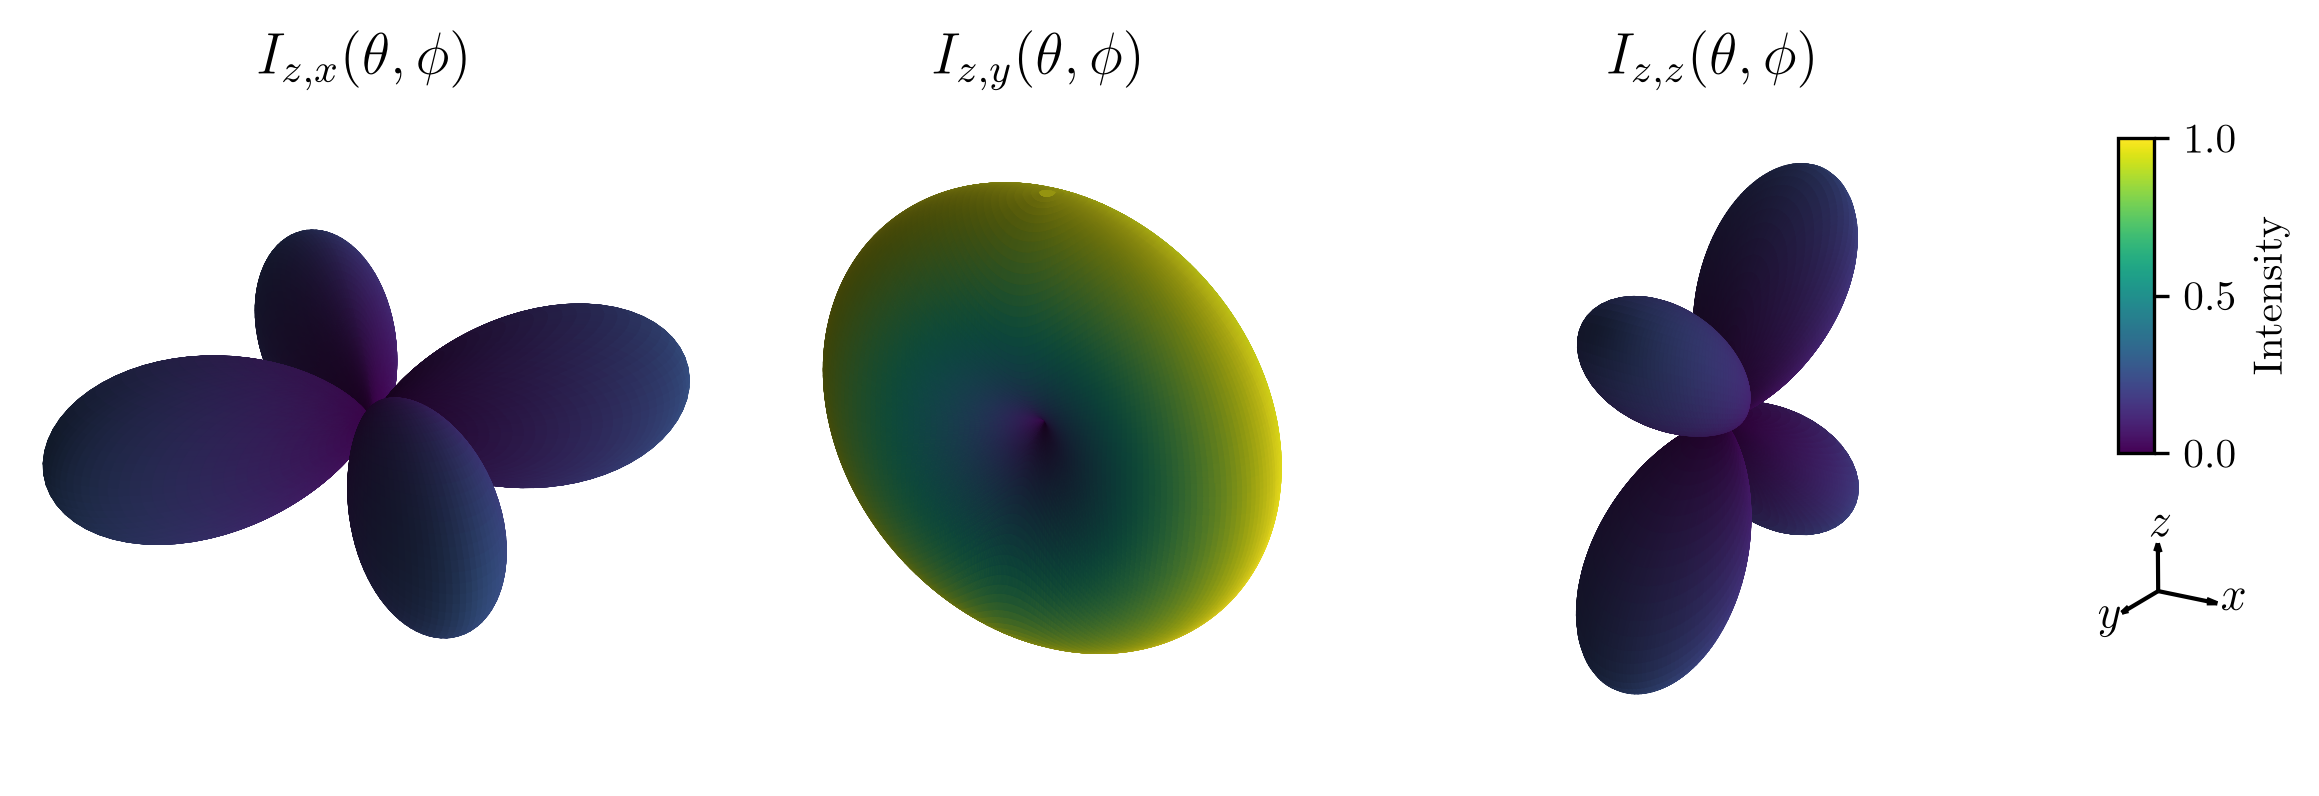

In [7]:
E_plus_z, E_minus_z, dE_z = librational_scattered_farfield(geometry=geometry, step_nm=ELLIPSOID_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=2, 
                                                           angle_deg=DEFAULT_LIBRATION_ANGLE_DEG, **farfield_params)
I_z_total, I_z_Ex, I_z_Ey, I_z_Ez = info_patterns_from_scattered_field(dE=dE_z, delta_mu=np.deg2rad(DEFAULT_LIBRATION_ANGLE_DEG), wavelength_nm=DEFAULT_WAVELENGTH_NM, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, 
                     figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_z_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, scale_list=[0.34, 0.34, 0.4], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_z_3d", results_dir=results_dir)

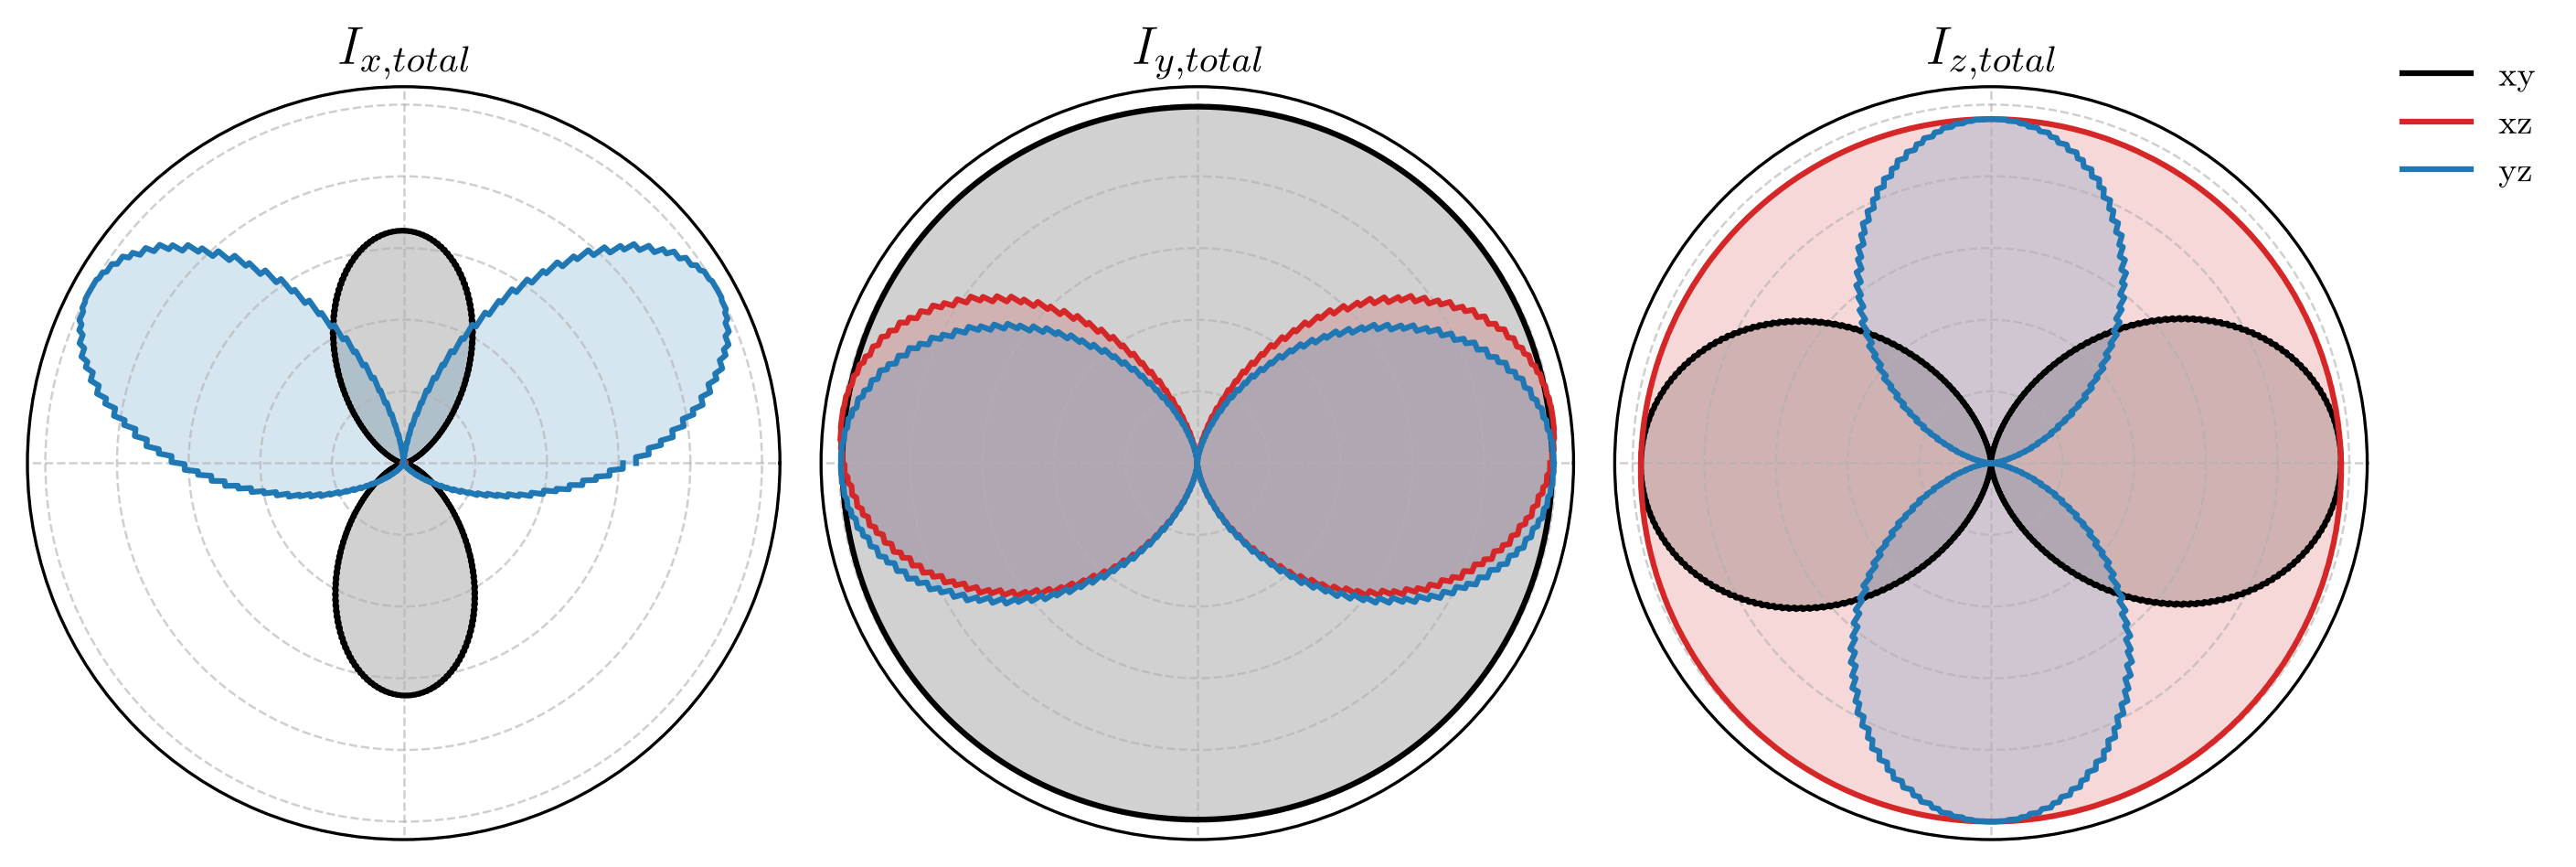

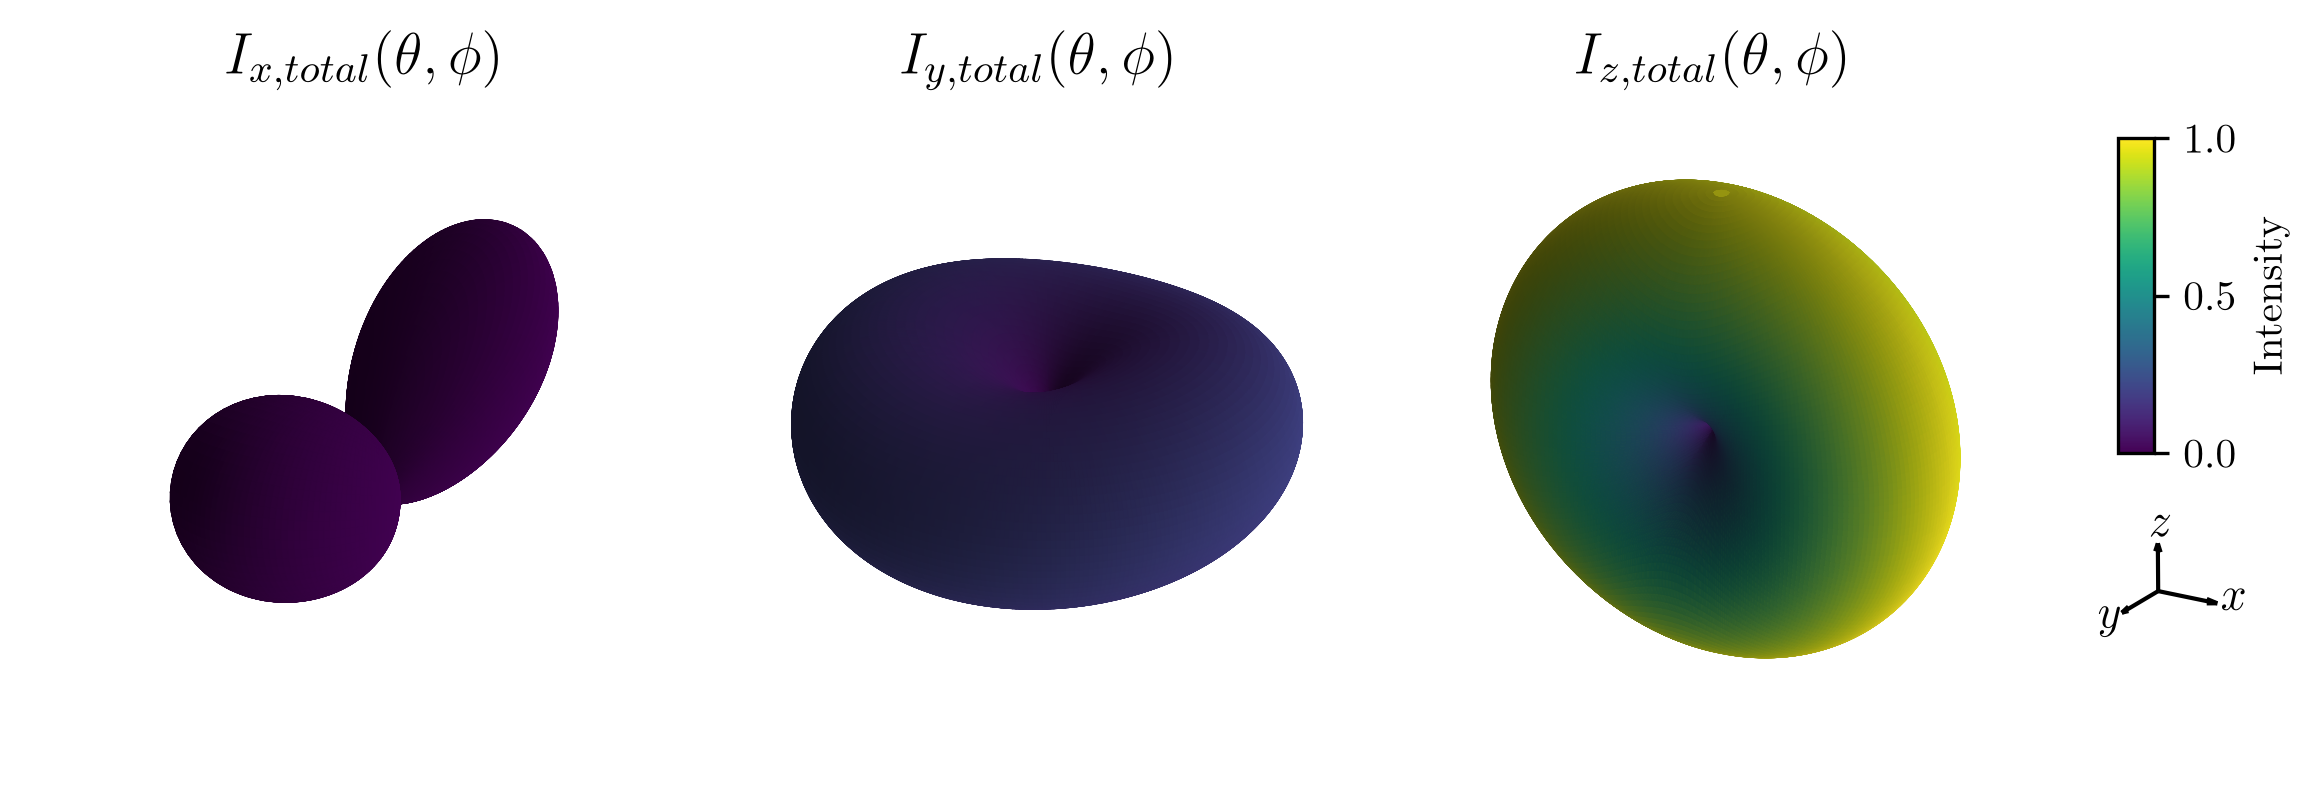

In [8]:
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_total_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, 
                     scale_list=[0.28, 0.34, 0.34], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="info_patterns_total_3d", results_dir=results_dir)